In [ ]:
# Korelasi adalah ukuran statistik yang menunjukkan kekuatan dan arah hubungan antara dua pemboleh ubah.

# 1. Korelasi Pearson (Pearson's r)
# Jenis Data: Kuantitatif berskala interval atau nisbah.
# Asumsi: Data mendekati taburan normal; hubungan linear antara pemboleh ubah.
# Julat Nilai: –1 hingga +1.
# +1: hubungan linear positif sempurna
# –1: hubungan linear negatif sempurna
# 0: tiada hubungan linear
# Sensitif kepada Outlier: Sangat sensitif — satu nilai ekstrem boleh mengubah nilai r dengan ketara.
# Interpretasi: Mengukur kekuatan dan arah linear antara dua pemboleh ubah.

# 2. Korelasi Spearman (Spearman's Rho, ρ)
# Jenis Data: Data ordinal atau kuantitatif yang boleh disusun mengikut kedudukan (ranking).
# Asumsi: Tidak mengandaikan taburan normal; sesuai untuk hubungan monotonik (naik atau turun secara konsisten).
# Julat Nilai: –1 hingga +1.
# +1: hubungan monotonik positif sempurna
# –1: hubungan monotonik negatif sempurna
# 0: tiada hubungan monotonik
# Robust kepada Outlier: Sederhana tahan terhadap nilai ekstrem kerana menggunakan kedudukan (ranking) bukan nilai sebenar.
# Interpretasi: Mengukur kekuatan dan arah monotonik antara dua pemboleh ubah berdasarkan kedudukan relatif data.

# 3. Korelasi Kendall (Kendall's Tau, τ)
# Jenis Data: Data ordinal atau kuantitatif yang boleh disusun mengikut kedudukan (ranking).
# Asumsi: Tidak mengandaikan taburan normal; sesuai untuk korelasi monotonik (bukan semestinya linear).
# Julat Nilai: –1 hingga +1.
# +1: semua pasangan adalah concordant (susunan sama)
# –1: semua pasangan adalah discordant (susunan bertentangan)
# 0: bilangan pasangan concordant sama dengan discordant
# Robust kepada Outlier: Lebih tahan badan terhadap nilai ekstrem kerana hanya bergantung pada kedudukan relatif (ranking).
# Interpretasi: Mengukur kekuatan dan arah monotonik antara dua pemboleh ubah berdasarkan bilangan pasangan concordant vs. discordant.

In [1]:
import pandas as pd
import numpy as np

# === Step 1: Muat naik dan sediakan data ===
df = pd.read_csv('ds/insdn_ddos_binary_0n1d.csv')

# Buang lajur label (anggap lajur bernama 'Label')
features = df.drop(columns=['Label'], errors='ignore')

# Pilih hanya lajur bertip nombor (buang kategori/teks)
features = features.select_dtypes(include=[np.number])

# === Step 2: Kira matriks korelasi Pearson, Spearman dan Kendall ===
pearson_corr = features.corr(method='pearson')
spearman_corr = features.corr(method='spearman')
kendall_corr = features.corr(method='kendall')

# === Step 3: Ekstrak nilai korelasi bagi setiap pasangan ciri ===
def extract_upper_triangle(corr_matrix):
    """Ambil nilai segitiga atas (tanpa diagonal), dan kembalikan nilai absolut."""
    mask = np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
    return corr_matrix.where(mask).stack().abs()

pearson_vals  = extract_upper_triangle(pearson_corr)
spearman_vals = extract_upper_triangle(spearman_corr)
kendall_vals  = extract_upper_triangle(kendall_corr)

# === Step 4: Kira statistik ringkas (purata & sisihan piawai) ===
pearson_mean,  pearson_std  = pearson_vals.mean(),  pearson_vals.std()
spearman_mean, spearman_std = spearman_vals.mean(), spearman_vals.std()
kendall_mean,  kendall_std  = kendall_vals.mean(),  kendall_vals.std()

print("=== Statistik Korelasi ===")
print(f"Purata Pearson:  {pearson_mean:.4f} | Sisihan Piawai: {pearson_std:.4f}")
print(f"Purata Spearman: {spearman_mean:.4f} | Sisihan Piawai: {spearman_std:.4f}")
print(f"Purata Kendall:  {kendall_mean:.4f} | Sisihan Piawai: {kendall_std:.4f}")

# === Step 5: Tafsiran hasil korelasi ===
def interpret_corr(name, mean, std):
    if mean > 0.5:
        strength = "kuat"
    elif mean > 0.3:
        strength = "sederhana"
    else:
        strength = "lemah atau tidak ketara"
    print(f"- {name} ≈ {mean:.2f} ± {std:.2f}: Hubungan {strength}.")

print("\n=== Tafsiran ===")
interpret_corr("Pearson r",  pearson_mean,  pearson_std)
interpret_corr("Spearman ρ", spearman_mean, spearman_std)
interpret_corr("Kendall τ",  kendall_mean,  kendall_std)

# === Step 6: Cadangan kaedah korelasi berdasarkan perbandingan ===
print("\n=== Cadangan Penggunaan Korelasi ===")
# Pilih kaedah yang mempunyai nilai purata tertinggi & sisihan terendah
means = {'Pearson': pearson_mean, 'Spearman': spearman_mean, 'Kendall': kendall_mean}
stds  = {'Pearson': pearson_std,  'Spearman': spearman_std,  'Kendall': kendall_std}

# Cari metric “terbaik” dalam aspek purata> dan sisihan<
best_mean = max(means, key=means.get)
best_std  = min(stds,  key=stds.get)

if best_mean == best_std:
    # Metrik sama untuk purata tertinggi & sisihan terendah
    print(f"- Data paling sesuai menggunakan **{best_mean}** "
          f"(purata tertinggi dan sisihan piawai terendah).")
else:
    print("- Corak bercampur; tiada satu metrik unggul mutlak.")
    print(f"- Purata tertinggi: **{best_mean}**; Sisihan piawai terendah: **{best_std}**.")
    print("- Fokus pada Spearman untuk keseimbangan linear & monotonik.")

# (Opsional) Simpan matriks korelasi ke CSV untuk analisis lanjut atau visualisasi
# pearson_corr.to_csv("pearson_correlation.csv")
# spearman_corr.to_csv("spearman_correlation.csv")
# kendall_corr.to_csv("kendall_correlation.csv")

=== Statistik Korelasi ===
Purata Pearson:  0.1635 | Sisihan Piawai: 0.2440
Purata Spearman: 0.5368 | Sisihan Piawai: 0.2752
Purata Kendall:  0.4796 | Sisihan Piawai: 0.2533

=== Tafsiran ===
- Pearson r ≈ 0.16 ± 0.24: Hubungan lemah atau tidak ketara.
- Spearman ρ ≈ 0.54 ± 0.28: Hubungan kuat.
- Kendall τ ≈ 0.48 ± 0.25: Hubungan sederhana.

=== Cadangan Penggunaan Korelasi ===
- Corak bercampur; tiada satu metrik unggul mutlak.
- Purata tertinggi: **Spearman**; Sisihan piawai terendah: **Pearson**.
- Fokus pada Spearman untuk keseimbangan linear & monotonik.


In [ ]:
# ML Classification

In [42]:
import pandas as pd
import numpy as np
import time
from scipy.stats import kendalltau
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, mean_squared_error, r2_score

# === Step 1: Muat naik data ===
df = pd.read_csv('ds/insdn_ddos_binary_0n1d.csv')
features = df.drop(columns=['Label'], errors='ignore').select_dtypes(include=[np.number])
label    = df['Label']

# === Step 1.1: Buang ciri konstankan ===
const_feats = features.columns[features.nunique() <= 1].tolist()
features = features.drop(columns=const_feats, errors='ignore')

# === Step 2: Kira Kendall τ setiap ciri vs. label ===
kendall_scores = {}
for col in features.columns:
    x = features[col].values
    if np.all(x == x[0]) or np.all(label.values == label.values[0]):
        continue
    kt, _ = kendalltau(x, label.values)
    kendall_scores[col] = abs(kt)

# === Step 3: Pilih Top-N ciri berdasarkan Kendall τ ===
N = 9
top_kendall = sorted(kendall_scores, key=kendall_scores.get, reverse=True)[:N]
print("Top-9 Features by Kendall τ:", top_kendall)

X = features[top_kendall]
y = label

# === Step 4: Split data ===
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=0
)

# === Step 5: Latih dan ukur masa ===
clf = DecisionTreeClassifier(random_state=0)

t0 = time.time()
clf.fit(X_train, y_train)
train_time = time.time() - t0

t1 = time.time()
y_pred  = clf.predict(X_test)
y_proba = clf.predict_proba(X_test)[:,1]
test_time = time.time() - t1

# === Step 6: Kira metrik ===
acc = accuracy_score(y_test, y_pred)
roc = roc_auc_score(y_test, y_proba)
mse = mean_squared_error(y_test, y_pred)
r2  = r2_score(y_test, y_pred)

print("\nDecision Tree Performance (Top-9 by Kendall τ)")
print(f"Accuracy          : {acc:.6f}")
print(f"ROC AUC           : {roc:.6f}")
print(f"Mean Squared Error: {mse:.6f}")
print(f"R² Score          : {r2:.6f}")
print(f"Training Time (s) : {train_time:.6f}")
print(f"Test Time (s)     : {test_time:.6f}")


Top-9 Features by Kendall τ: ['Protocol', 'Bwd Header Len', 'Tot Fwd Pkts', 'Subflow Fwd Pkts', 'Fwd Header Len', 'Fwd Pkts/s', 'Fwd Act Data Pkts', 'Pkt Len Max', 'Pkt Size Avg']

Decision Tree Performance (Top-9 by Kendall τ)
Accuracy          : 0.999860
ROC AUC           : 0.999828
Mean Squared Error: 0.000140
R² Score          : 0.999394
Training Time (s) : 0.098059
Test Time (s)     : 0.016557


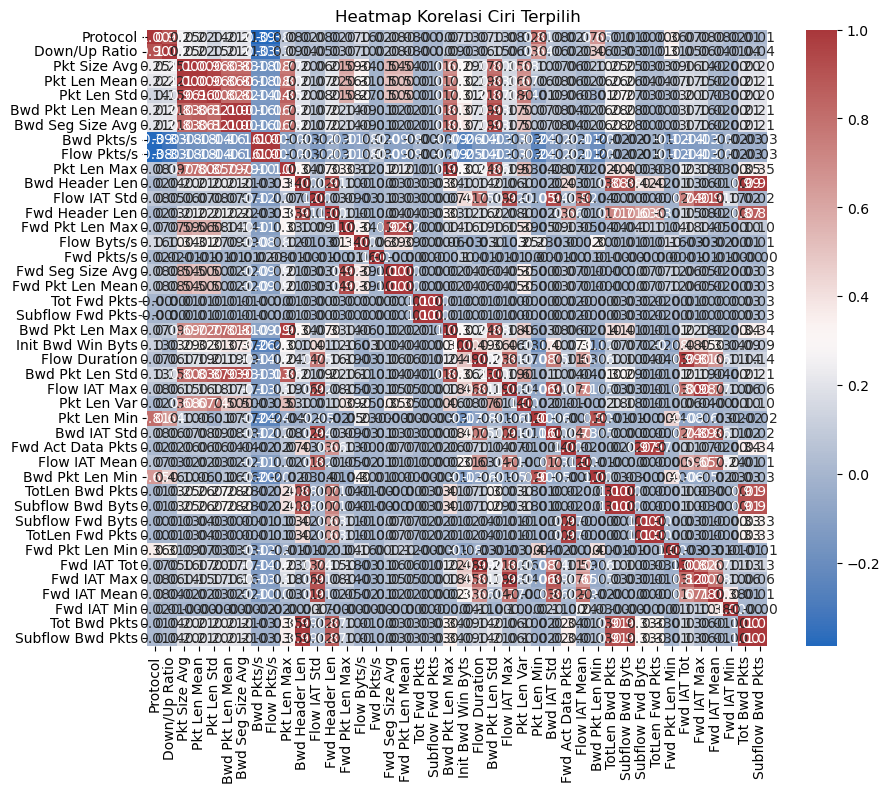

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(df_selected.corr(), annot=True, fmt=".2f", cmap="vlag")
plt.title("Heatmap Korelasi Ciri Terpilih")
plt.show()